# Análisis Inteligente del Consumo Energético

El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de clasificar el nivel de eficiencia energética de una vivienda o pequeño establecimiento a partir de diferentes características relacionadas con el consumo eléctrico.

Se generará un dataset sintético que represente distintos perfiles de consumo.

Posteriormente se realizará un análisis exploratorio de los datos (EDA), el entrenamiento de modelos supervisados y la evaluación de su desempeño para seleccionar el modelo más adecuado.

# Variables del Dataset

Para representar el comportamiento energético de una vivienda se seleccionaron las siguientes variables.

1. Fecha

      Tipo: Fecha (YYYY-MM)

      -Representa el período al que corresponde el consumo energético registrado.

      Permite realizar análisis temporales como:

      -Evolución del consumo.

      -Comparación entre meses.

      -Tendencias de eficiencia.

      -Variaciones estacionales.

2. Consumo mensual (kWh)

      Tipo: Numérica

      Representa la cantidad de energía consumida durante un mes.

      Es la variable principal del problema y será utilizada para:

      -Estimar el costo mensual.

      -Analizar patrones de consumo.

      -Detectar consumos elevados.
      
3. Uso en horario pico

      Tipo: Booleana

      Indica si la mayor parte del consumo ocurre durante los horarios de mayor demanda eléctrica.

      Su análisis permite:

      -Detectar hábitos poco eficientes.

      -Generar recomendaciones para redistribuir el consumo.

4. Horas de alto consumo

      Tipo: Numérica

      Cantidad aproximada de horas diarias durante las cuales el consumo eléctrico es elevado.

      Permite identificar:

      -Intensidad del uso energético.

      -Relación entre tiempo de uso y consumo mensual.

5. Cantidad de equipos eléctricos

      Tipo: Numérica

      Número de electrodomésticos o equipos eléctricos utilizados regularmente.

      -Esta variable permite analizar cómo influye la cantidad de dispositivos sobre el consumo energético.

6. Cantidad de personas

      Tipo: Numérica

      -Cantidad de personas que habitan el inmueble.

      Se incorpora debido a que el consumo suele aumentar con el número de habitantes.

7. Tipo de inmueble

      Tipo: Categórica

      Puede tomar los valores:

      -Casa

      -Departamento

      -Comercio

      Permite analizar diferencias de consumo entre distintos tipos de establecimientos.

8. Categoría de eficiencia energética (Target)

      Tipo: Categórica

      Representa la clasificación que el modelo deberá aprender.

      Se utilizarán tres categorías:

      -Eficiente

      -Moderado
      
      -Ineficiente

      Las etiquetas serán generadas mediante un conjunto de reglas que consideran el consumo energético y otros factores relacionados con los hábitos de uso.

# Generación del Dataset

Se desarrolló un generador de datos sintéticos.

El objetivo es representar distintos perfiles de consumo energético manteniendo relaciones coherentes entre las variables.

Se generarán 1000 registros correspondientes a distintos inmuebles con características variadas.

Posteriormente estas observaciones serán utilizadas para entrenar y evaluar modelos supervisados de clasificación.

In [7]:
import random
import pandas as pd
from datetime import datetime

# AB_sugerencia -> ¿aquí podríamos insertar random.seed(42)?
random.seed(42)

NUM_REGISTROS = 1000

TIPOS_INMUEBLE = [
    "Casa",
    "Departamento",
    "Comercio"
]
def generar_fecha():
    año = random.randint(2023, 2025)
    mes = random.randint(1, 12)
    return datetime(año, mes, 1).strftime("%Y-%m")


def generar_tipo():
    return random.choices(
        TIPOS_INMUEBLE,
        weights=[50, 35, 15]
    )[0]


def generar_personas(tipo):

    if tipo == "Casa":
        return random.randint(2, 6)

    elif tipo == "Departamento":
        return random.randint(1, 4)

    return random.randint(2, 8)


def generar_equipos(personas):
    return random.randint(personas + 2, personas + 10)


def generar_horas(): #AB_sugerencia: ¿se podría escribir así: def generar_horas_alto_consumo():?
    return random.randint(2, 12)


def generar_horario_pico():
    return random.random() < 0.65


def calcular_consumo(personas, equipos, horas, horario_pico):

    consumo = 80

    consumo += personas * random.randint(20, 35)

    consumo += equipos * random.randint(6, 10)

    consumo += horas * random.randint(8, 15) #AB_sugerencia ->  ¿se podría escribir horas_alto_consumo en lugar de horas?

    if horario_pico:
        consumo += random.randint(20, 50)

    consumo += random.randint(-15, 15)

    return max(consumo, 100)

#Indice para calcular categoria

def calcular_indice(consumo,
                    horario_pico,
                    horas,
                    equipos,
                    personas):

    indice = 100

    if consumo > 600:
        indice -= 40
    elif consumo > 450:
        indice -= 25
    elif consumo > 300:
        indice -= 10

    if horario_pico:
        indice -= 15

    if horas >= 10:
        indice -= 15
    elif horas >= 7:
        indice -= 8


    if equipos >= 15:
        indice -= 15
    elif equipos >= 10:
        indice -= 8


    if personas >= 5:
        indice -= 5

    indice += random.randint(-8, 8)

    indice = max(0, min(indice, 100))

    return indice

def clasificar(indice):

    if indice >= 75:
        return "Eficiente"

    elif indice >= 45:
        return "Moderado"

    return "Ineficiente"


def generar_registro():

    tipo = generar_tipo()

    personas = generar_personas(tipo)

    equipos = generar_equipos(personas)

    horas = generar_horas() #AB_sugerencia -> ¿se puede escribir aquí horas_alto_consumo = generar_horas_alto_consumo()?

    horario_pico = generar_horario_pico()

    consumo = calcular_consumo(
        personas,
        equipos,
        horas,
        horario_pico
    )

    indice = calcular_indice(
        consumo,
        horario_pico,
        horas,
        equipos,
        personas
    )

    categoria = clasificar(indice)

    return {
        "fecha": generar_fecha(),
        "consumo_kwh": consumo,
        "uso_horario_pico": horario_pico,
        "horas_alto_consumo": horas,
        "cantidad_equipos": equipos,
        "cantidad_personas": personas,
        "tipo_inmueble": tipo,
        "categoria": categoria
    }

dataset = []

for _ in range(NUM_REGISTROS):
    dataset.append(generar_registro())

df = pd.DataFrame(dataset)

df.to_csv(
    "consumo_energetico.csv",
    index=False,
    encoding="utf-8"
)

print(df.head())

print("\nDistribución de categorías:")
print(df["categoria"].value_counts())

     fecha  consumo_kwh  uso_horario_pico  horas_alto_consumo  \
0  2023-02          254              True                   5   
1  2023-12          515              True                  10   
2  2024-06          290             False                   5   
3  2025-04          343              True                  10   
4  2025-06          220             False                   6   

   cantidad_equipos  cantidad_personas tipo_inmueble    categoria  
0                 7                  1  Departamento    Eficiente  
1                 8                  6          Casa  Ineficiente  
2                 8                  4          Casa    Eficiente  
3                10                  1  Departamento     Moderado  
4                 6                  1  Departamento    Eficiente  

Distribución de categorías:
categoria
Moderado       547
Eficiente      355
Ineficiente     98
Name: count, dtype: int64


#Conociendo el Data Set

In [8]:
import pandas as pd
import numpy as np
df = pd.read_csv("consumo_energetico.csv")

In [9]:
print("Primeros registros")
df.head()

Primeros registros


,fecha,consumo_kwh,uso_horario_pico,horas_alto_consumo,cantidad_equipos,cantidad_personas,tipo_inmueble,categoria
0,2023-02,254,True,5,7,1,Departamento,Eficiente
1,2023-12,515,True,10,8,6,Casa,Ineficiente
2,2024-06,290,False,5,8,4,Casa,Eficiente
3,2025-04,343,True,10,10,1,Departamento,Moderado
4,2025-06,220,False,6,6,1,Departamento,Eficiente


In [10]:
print("Últimos registros")
df.tail()

Últimos registros


,fecha,consumo_kwh,uso_horario_pico,horas_alto_consumo,cantidad_equipos,cantidad_personas,tipo_inmueble,categoria
995,2025-04,349,True,5,9,3,Casa,Moderado
996,2024-04,362,True,3,12,5,Casa,Moderado
997,2024-06,320,False,5,12,2,Departamento,Eficiente
998,2023-08,401,True,8,10,2,Casa,Moderado
999,2024-01,282,False,6,10,2,Casa,Eficiente


In [11]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 1000
Columnas: 8


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   fecha               1000 non-null   object
 1   consumo_kwh         1000 non-null   int64 
 2   uso_horario_pico    1000 non-null   bool  
 3   horas_alto_consumo  1000 non-null   int64 
 4   cantidad_equipos    1000 non-null   int64 
 5   cantidad_personas   1000 non-null   int64 
 6   tipo_inmueble       1000 non-null   object
 7   categoria           1000 non-null   object
dtypes: bool(1), int64(4), object(3)
memory usage: 55.8+ KB


In [13]:
df.describe()

,consumo_kwh,horas_alto_consumo,cantidad_equipos,cantidad_personas
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,361.000000,6.955000,9.708000,3.685000
std,79.346366,3.149745,3.046312,1.700784
min,153.000000,2.000000,3.000000,1.000000
25%,306.000000,4.000000,7.000000,2.000000
50%,355.000000,7.000000,10.000000,3.500000
75%,415.250000,10.000000,12.000000,5.000000
max,683.000000,12.000000,18.000000,8.000000


In [14]:
print("Consumo promedio")

df["consumo_kwh"].mean()

Consumo promedio


np.float64(361.0)

In [15]:
print("Consumo mínimo")
print(df["consumo_kwh"].min())

print("Consumo máximo")
print(df["consumo_kwh"].max())

Consumo mínimo
153
Consumo máximo
683


In [16]:
TARIFA = 0.75

df["costo_estimado"] = df["consumo_kwh"] * TARIFA

In [17]:
print("Costo promedio mensual")

df["costo_estimado"].mean()

Costo promedio mensual


np.float64(270.75)

In [18]:
df["costo_estimado"].describe()

,costo_estimado
count,1000.000000
mean,270.750000
std,59.509775
min,114.750000
25%,229.500000
50%,266.250000
75%,311.437500
max,512.250000


In [19]:
df["categoria"].value_counts()

,count
categoria,
Moderado,547
Eficiente,355
Ineficiente,98


In [20]:
round(
    df["categoria"].value_counts(normalize=True)*100,
    2
)

,proportion
categoria,
Moderado,54.7
Eficiente,35.5
Ineficiente,9.8


In [21]:
df["tipo_inmueble"].value_counts()

,count
tipo_inmueble,
Casa,494
Departamento,350
Comercio,156


In [22]:
round(
    df["tipo_inmueble"].value_counts(normalize=True)*100,
    2
)

,proportion
tipo_inmueble,
Casa,49.4
Departamento,35.0
Comercio,15.6


In [23]:
df["uso_horario_pico"].value_counts()

,count
uso_horario_pico,
True,630
False,370


In [24]:
round(
    df["uso_horario_pico"].value_counts(normalize=True)*100,
    2
)

,proportion
uso_horario_pico,
True,63.0
False,37.0


In [25]:
df.groupby("tipo_inmueble")["consumo_kwh"].mean().sort_values(ascending=False)

,consumo_kwh
tipo_inmueble,
Comercio,403.057692
Casa,374.042510
Departamento,323.845714


In [26]:
df.groupby("categoria")["consumo_kwh"].mean()

,consumo_kwh
categoria,
Eficiente,297.754930
Ineficiente,493.551020
Moderado,378.297989


#Gráficos

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg # Se carga módulo para exportar imagen del Logo

# ==========================================================
# LOGO LEAF WATT
# ==========================================================

logo = mpimg.imread("Logo LW(collab).png")


# ==========================================================
# FUNCIÓN PARA AGREGAR EL LOGO
# ==========================================================

def agregar_logo():
    """
    Agrega el logo de Leaf Watt en una zona reservada
    de la figura para evitar que se superponga con los datos.
    """

    fig = plt.gcf()

    logo_ax = fig.add_axes(
        [0.86, 0.80, 0.12, 0.15]
    )

    logo_ax.imshow(logo)
    logo_ax.axis("off")


# ==========================================================
# PALETA DE COLORES
# ==========================================================

PALETA_LEAF_WATT = [
    "#0B5345",  # Verde oscuro
    "#117A65",  # Verde profundo
    "#229954",  # Verde principal
    "#52BE80",  # Verde medio
    "#8ED14F",  # Verde lima
    "#A9DFBF"   # Verde claro
]


# ==========================================================
# PALETA PARA TIPOS DE INMUEBLE
# ==========================================================

PALETA_INMUEBLE = [
    "#0B5345",
    "#229954",
    "#52BE80",
    "#8ED14F",
    "#A9DFBF"
]


# ==========================================================
# FORMATO GENERAL
# ==========================================================

def formato(ax, titulo, xlabel, ylabel, leyenda=False):
    """Aplica el mismo formato a todos los gráficos."""

    plt.setp(ax.spines.values(),color="black",linewidth=1)

    if leyenda and ax.get_legend() is not None:
        plt.setp(ax.get_legend().get_frame(),
            edgecolor="black",
            linewidth=1)

    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Dejamos espacio a la derecha para el logo
    plt.tight_layout(rect=[0, 0, 0.84, 1])

    # Logo Leaf Watt
    agregar_logo()

    plt.show()


def funcion_graficos(df):

    sns.set_theme(style="whitegrid")


    # Paleta de colores
    orden = df["categoria"].value_counts().index
    colores = PALETA_LEAF_WATT[:len(orden)] #Se coloca la paleta de colores definida.
    palette = dict(zip(orden, colores))


    # ==========================================================
    # Distribución de categorías
    # ==========================================================

    plt.figure(figsize=(7,5))

    ax = sns.countplot(
        data=df,
        x="categoria",
        hue="categoria",
        order=orden,
        palette=palette,
        edgecolor="black",
        linewidth=0.8
    )

    formato(
        ax,
        "Distribución de categorías de eficiencia",
        "Categoría",
        "Cantidad"
    )


    # ==========================================================
    # Costo promedio por categoría
    # ==========================================================

    costo_categoria = (
        df.groupby("categoria")["costo_estimado"]
        .mean()
        .reset_index()
        .sort_values("costo_estimado")
    )

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=costo_categoria,
        x="categoria",
        y="costo_estimado",
        hue="categoria",
        palette=palette,
        edgecolor="black",
        linewidth=0.8
    )

    formato(
        ax,
        "Costo promedio por categoría",
        "Categoría",
        "Costo promedio"
    )


    # ==========================================================
    # Equipos vs consumo
    # ==========================================================

    plt.figure(figsize=(8,5))

    ax = sns.scatterplot(
        data=df,
        x="cantidad_equipos",
        y="consumo_kwh",
        hue="categoria",
        palette=palette
    )

    formato(
        ax,
        "Relación entre cantidad de equipos y consumo",
        "Cantidad de equipos",
        "Consumo (kWh)",
        leyenda=True
    )


    # ==========================================================
    # Horas de alto consumo vs consumo
    # ==========================================================

    plt.figure(figsize=(8,5))

    ax = sns.scatterplot(
        data=df,
        x="horas_alto_consumo",
        y="consumo_kwh",
        hue="categoria",
        palette=palette
    )

    formato(
        ax,
        "Impacto de las horas de alto consumo",
        "Horas de alto consumo",
        "Consumo (kWh)",
        leyenda=True
    )


    # ==========================================================
    # Costo por tipo de inmueble
    # ==========================================================

    costo_tipo = (
        df.groupby("tipo_inmueble")["costo_estimado"]
        .mean()
        .reset_index()
        .sort_values("costo_estimado")
    )

    # Creamos una paleta según la cantidad de tipos
    colores_tipo = sns.color_palette(
        "Greens",
        n_colors=len(costo_tipo)
    )

    palette_tipo = dict(
        zip(
            costo_tipo["tipo_inmueble"],
            colores_tipo
        )
    )

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=costo_tipo,
        x="tipo_inmueble",
        y="costo_estimado",
        hue="tipo_inmueble",
        palette=palette_tipo,
        edgecolor="black",
        linewidth=0.8
    )

    formato(
        ax,
        "Costo promedio por tipo de inmueble",
        "Tipo de inmueble",
        "Costo promedio"
    )


    # ==========================================================
    # Tipo de inmueble por categoría
    # ==========================================================

    plt.figure(figsize=(8,5))

    ax = sns.countplot(
        data=df,
        x="categoria",
        hue="tipo_inmueble",
        palette=PALETA_INMUEBLE, # Se cambia la paleta de Inmuebles antes definida.
        edgecolor="black",
        linewidth=0.8
    )

    formato(
        ax,
        "Tipo de inmueble por eficiencia energética",
        "Categoría",
        "Cantidad",
        leyenda=True
    )


    # ==========================================================
    # Histograma del consumo
    # ==========================================================

    plt.figure(figsize=(8,5))

    ax = sns.histplot(
        df["consumo_kwh"],
        bins=30,
        kde=True,
        color="#229954",
        edgecolor="black",
        linewidth=0.6
    )

    formato(
        ax,
        "Distribución del consumo energético",
        "Consumo (kWh)",
        "Cantidad de inmuebles"
    )


    # ==========================================================
    # Heatmap costo promedio
    # ==========================================================

    tabla = df.pivot_table(
        values="costo_estimado",
        index="tipo_inmueble",
        columns="categoria",
        aggfunc="mean"
    )

    tabla = tabla[["Eficiente","Moderado","Ineficiente"]]

    plt.figure(figsize=(7,4))
    ax = sns.heatmap(
        tabla,
        annot=True,
        cmap=sns.light_palette("#229954",as_cmap=True), # Se cambio para que tenga coherencia con el Logo.
        fmt=".1f"
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    plt.title("Costo promedio por tipo y categoría")
    plt.tight_layout( rect=[0, 0, 0.84, 1])
    agregar_logo()
    plt.show()


    # ==========================================================
    # Matriz de correlación
    # ==========================================================

    correlacion = (
        df.select_dtypes(include=["int64", "float64"])
        .corr()
    )

    plt.figure(figsize=(8,6))
    ax = sns.heatmap(
        correlacion,
        annot=True,
        cmap=sns.diverging_palette(150,10,as_cmap=True),# Se cambio a una paleta Divergente, para no forzar
               # todo a Verde. Puesto a que hay que distinguir las correlaciones negativas de la positivas.
        fmt=".2f"
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    plt.title("Correlación entre variables")
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    agregar_logo()
    plt.show()

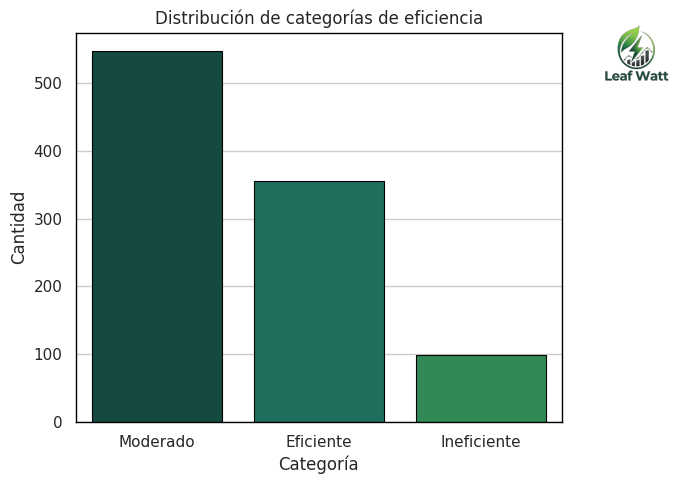

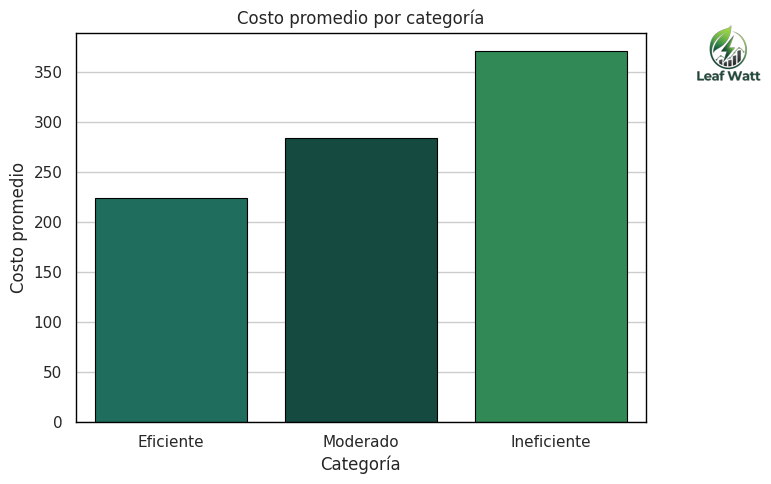

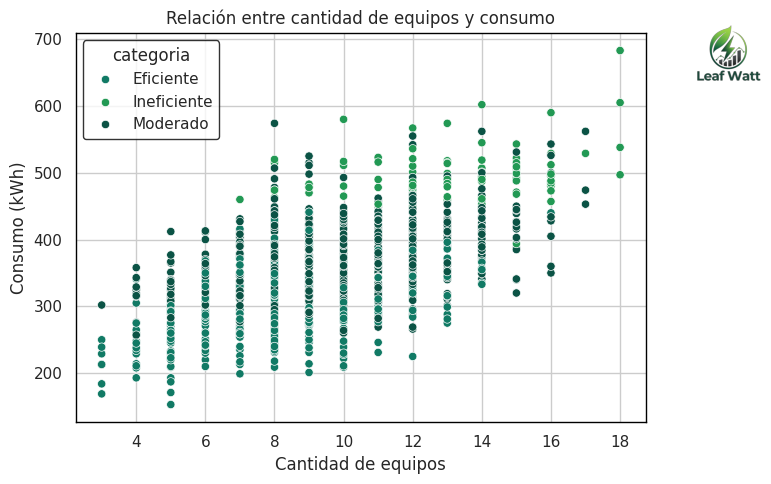

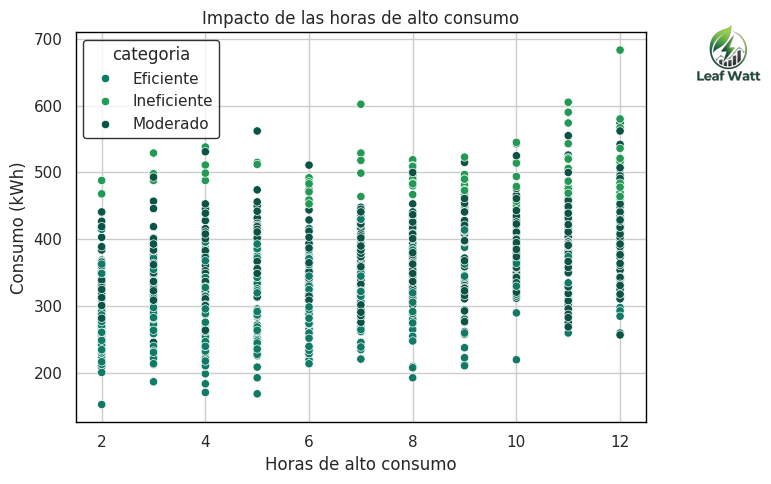

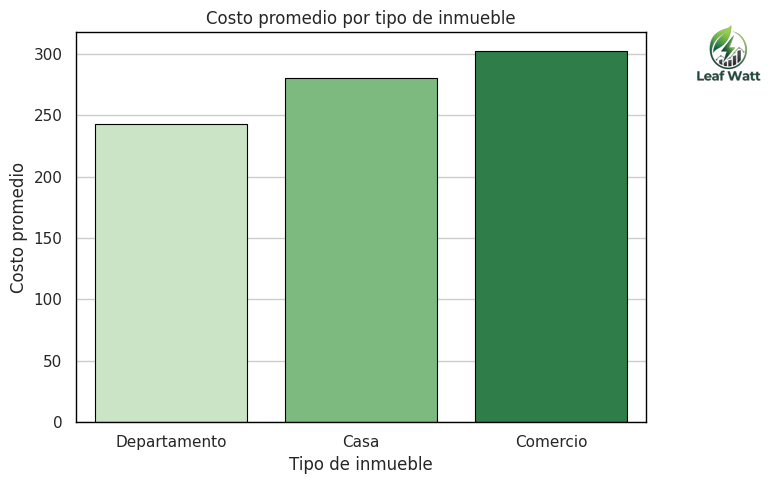

/tmp/ipykernel_530/2427085619.py:248: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.countplot(


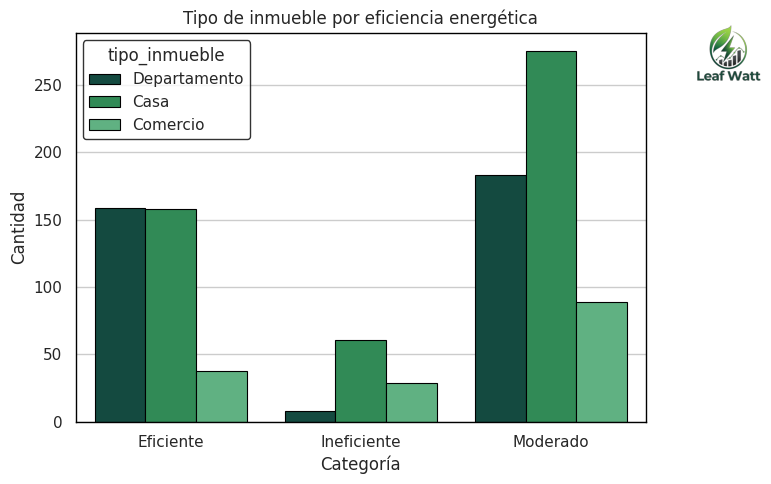

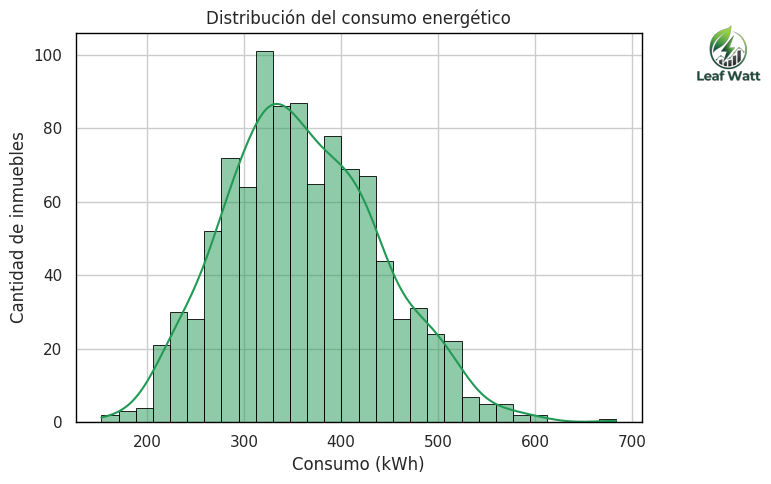

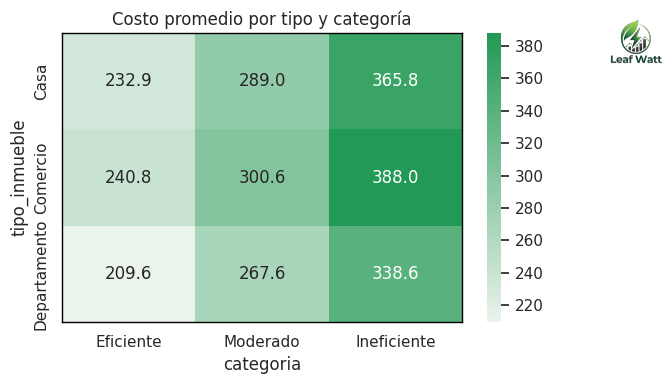

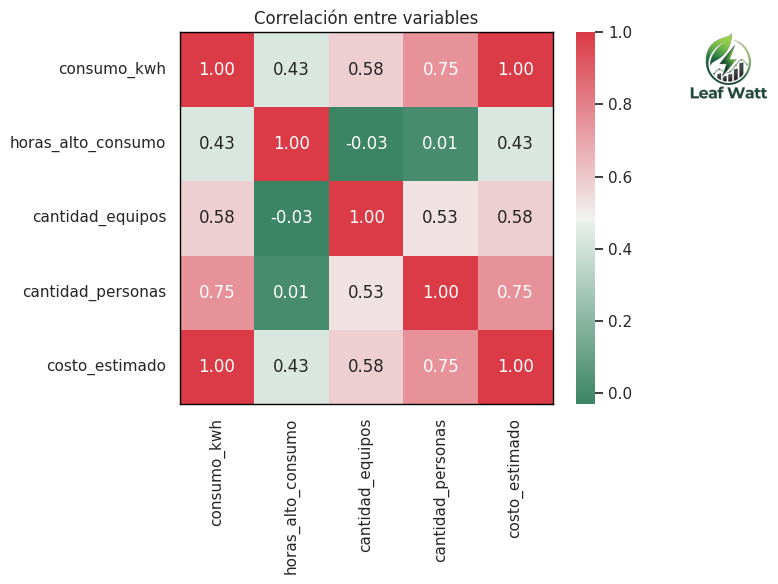

In [41]:
funcion_graficos(df)